In [1]:
!pip install ultralytics scikit-learn pandas opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings

warnings.filterwarnings("ignore")

# 1. Load the modified dataset
data = pd.read_csv("/content/fused_sensor_training_data_high_altitude.csv")

# 2. Define Features and Labels
X = data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'Temperature_C', 'ToF_Amplitude']]
y = data['Target_Label']

# 3. Create the Ensemble (The "Council")
clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2 = GradientBoostingClassifier(n_estimators=150, random_state=45)
clf3 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('gb', clf2), ('lr', clf3)],
    voting='soft'
)

# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=45, stratify=y)

print("Training Ensemble Model on Drone Data...")
ensemble_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = ensemble_model.predict(X_test)
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Save the Model
joblib.dump(ensemble_model, 'ensemble_sensor_model.pkl')
print("✅ Ensemble Model saved successfully as 'ensemble_sensor_model.pkl'")

Training Ensemble Model on Drone Data...
Ensemble Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

 Not Present       0.85      0.98      0.91     12337
      Victim       0.65      0.19      0.29      2663

    accuracy                           0.84     15000
   macro avg       0.75      0.58      0.60     15000
weighted avg       0.81      0.84      0.80     15000

✅ Ensemble Model saved successfully as 'ensemble_sensor_model.pkl'


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
1. Loading Ensemble Systems...
-> Loading YOLO AI...

2. Scanning image for humans with YOLO...

0: 1280x1056 19 persons, 121.7ms
Speed: 20.0ms preprocess, 121.7ms inference, 97.3ms postprocess per image at shape (1, 3, 1280, 1056)
Raw YOLO detections: 19

YOLO found shape at X:201, Y:592. Asking Ensemble for verification...
Ensemble sensor check: 3 pixels verified.

YOLO found shape at X:361, Y:592. Asking Ensemble for verification...
Ensemble sensor check: 1 pixels verified.

YOLO found shape at X:243, Y:598. Asking Ensemble for verification...
Ensemble sensor check: 4 pixels verified.

YOLO found shape at X:317, Y:581. Asking Ensemble for verification...
Ensemble sensor check: 

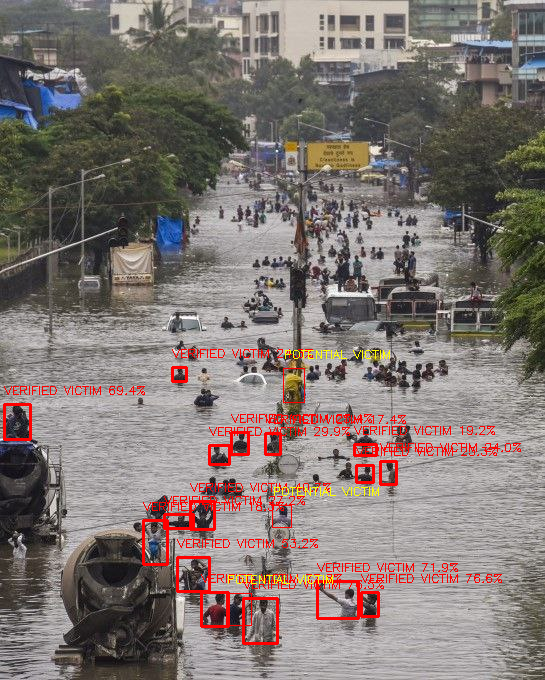

In [3]:
import cv2
import pandas as pd
import joblib
import os
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

print("1. Loading Ensemble Systems...")
# Load the ENSEMBLE model and the CSV
ensemble_model = joblib.load('ensemble_sensor_model.pkl')
sensor_data = pd.read_csv('/content/fused_sensor_training_data_high_altitude.csv')

# Load YOLO
print("-> Loading YOLO AI...")
yolo_model = YOLO('yolov8l.pt') # Downloads the large model automatically

# >>> IMPORTANT: Change this to the exact name of your uploaded image <<<
image_name = '/content/data/photo_2026-03-20_01-36-35.jpg' 

if not os.path.exists(image_name):
    print(f"ERROR: Image '{image_name}' not found. Did you upload it in Step 2?")
else:
    image = cv2.imread(image_name)
    
    # Run YOLO detection
    print("\n2. Scanning image for humans with YOLO...")
    results = yolo_model(image, classes=[0], conf=0.15, imgsz=1280)
    boxes = results[0].boxes
    
    print(f"Raw YOLO detections: {len(boxes)}")

    if len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = float(box.conf[0]) * 100
            x, y, w, h = int(x1), int(y1), int(x2 - x1), int(y2 - y1)

            print(f"\nYOLO found shape at X:{x}, Y:{y}. Asking Ensemble for verification...")

            # Filter sensor data within the YOLO bounding box
            box_data = sensor_data[
                (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
                (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
            ]

            if not box_data.empty:
                # Note: We now include Temperature_C as it was critical in the modified dataset
                features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'Temperature_C', 'ToF_Amplitude']]
                
                # The Ensemble predicts
                predictions = ensemble_model.predict(features)
                human_pixel_count = (predictions == 'Victim').sum()
                
                print(f"Ensemble sensor check: {human_pixel_count} pixels verified.")

                if human_pixel_count>0: #* Confirmed by both YOLO and the Ensemble
                
                    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                    cv2.putText(image, f"VERIFIED VICTIM {confidence:.1f}%", (x, y - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
                elif human_pixel_count==0: #* Rechecking is needed coz only one model identified the victims(YOLOV8) not by ensemble learning model
                   
                    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 1)
                    cv2.putText(image, "POTENTIAL VICTIM", (x, y - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
            else:
                print("No sensor data found in this exact pixel region.")
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 255), 1)
                cv2.putText(image, "NO SENSOR DATA", (x, y - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

    # Display final annotated image
    cv2_imshow(image)

# Backend Sections 

In [ ]:
!pip install flask pyngrok joblib

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import joblib
from ultralytics import YOLO
from flask import Flask, request, send_from_directory
from datetime import datetime
from pyngrok import ngrok
import threading

app = Flask(__name__, static_folder="Frontend", static_url_path="")

ensemble_model = joblib.load('ensemble_sensor_model.pkl')
sensor_data = pd.read_csv('/content/fused_sensor_training_data_high_altitude.csv')
yolo_model = YOLO('yolov8l.pt')

OUTPUT_DIR = os.path.join("Frontend", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULT_HTML_PATH = "/content/Frontend/result.html"

@app.get("/")
def index():
    return app.send_static_file("index.html")

@app.get("/output/<path:filename>")
def output_file(filename):
    return send_from_directory(OUTPUT_DIR, filename)

@app.post("/")
def process_image():
    if "image_file" not in request.files:
        return "No image uploaded", 400

    file = request.files["image_file"]
    if file.filename == "":
        return "Empty filename", 400

    file_bytes = np.frombuffer(file.read(), np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if image is None:
        return "Invalid image", 400

    results = yolo_model(image, classes=[0], conf=0.15, imgsz=1280)
    boxes = results[0].boxes
    if not boxes:
        boxes = []

    confirmed = False

    if len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = float(box.conf[0]) * 100
            x, y, w, h = int(x1), int(y1), int(x2 - x1), int(y2 - y1)

            box_data = sensor_data[
                (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
                (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
            ]

            if not box_data.empty:
                features = box_data[['Pixel_X','Pixel_Y','Depth_mm','Temperature_C','ToF_Amplitude']]
                predictions = ensemble_model.predict(features)
                human_pixel_count = (predictions == 'Victim').sum()

                if human_pixel_count > 0:
                    confirmed = True
                    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                    cv2.putText(image, f"VERIFIED VICTIM {confidence:.1f}%", (x, y - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
                else:
                    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 1)
                    cv2.putText(image, "POTENTIAL VICTIM", (x, y - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
            else:
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 255), 1)
                cv2.putText(image, "NO SENSOR DATA", (x, y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_name = f"output_{ts}.png"
    out_path = os.path.join(OUTPUT_DIR, out_name)
    cv2.imwrite(out_path, image)

    msg_text = "Confirmed: Victim Identified" if confirmed else "No victims found"
    msg_color = "#ff4d4d" if confirmed else "#41d07f"
    image_url = f"/output/{out_name}"

    with open(RESULT_HTML_PATH, "r", encoding="utf-8") as f:
        html = f.read()

    html = html.replace("{MSG_TEXT}", msg_text)
    html = html.replace("{MSG_COLOR}", msg_color)
    html = html.replace("{IMAGE_URL}", image_url)

    return html

def run_flask():
    app.run(host="0.0.0.0", port=8000, debug=False)

# Uncomment if you use a token
# ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

threading.Thread(target=run_flask).start()
public_url = ngrok.connect(8000)
print("Public URL:", public_url)

if __name__ == "__main__":
    pass


 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Public URL: NgrokTunnel: "https://1068-34-21-132-217.ngrok-free.app" -> "http://localhost:8000"


INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:00:27] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:00:28] "GET /style.css HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:00:28] "GET /bg1.png HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:00:29] "GET /favicon.ico HTTP/1.1" 404 -



0: 1280x1056 19 persons, 131.7ms
Speed: 7.7ms preprocess, 131.7ms inference, 2.0ms postprocess per image at shape (1, 3, 1280, 1056)


INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:00:42] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:00:43] "GET /output/output_20260403_220042.png HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:01:04] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:01:05] "GET /style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:01:06] "GET /bg1.png HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:02:05] "GET /style.css HTTP/1.1" 304 -



0: 1280x896 12 persons, 157.9ms
Speed: 13.0ms preprocess, 157.9ms inference, 2.3ms postprocess per image at shape (1, 3, 1280, 896)


INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:09] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:10] "GET /output/output_20260403_220309.png HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:44] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:45] "GET /style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:46] "GET /bg1.png HTTP/1.1" 304 -



0: 1280x1056 19 persons, 194.3ms
Speed: 7.9ms preprocess, 194.3ms inference, 1.5ms postprocess per image at shape (1, 3, 1280, 1056)


INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:56] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Apr/2026 22:03:57] "GET /output/output_20260403_220356.png HTTP/1.1" 200 -
